# 시나리오 설명

## Task 1 Process

Task 1 학습 및 결과 추출
* Task 1 의 데이터과 레이블은 구성되어 있다 가정함
* Task 1 에 대한 학습 진행 (Train 코드는 script 실행 활용, dist 사용 필요하기 때문)
* Task 1 에 대한 Predict unknown objects and save results

Prediction results 시각화
* 4가지 시각화 데이터 생성 
    1. Prediction
    2. Ground Truth \[Known & Unknown\]
    3. Known GT와 안 겹치는 Prediction: 이미 학습한 클래스를 제거하여 시각화
    4. Unknown GT와 겹치는 Prediction: Future GT class와 비교하여 얼마나 모델이 unknown objects를 포착하고 있는지 시각화 (우리의 편의를 위해 만든 뷰)

유저 피드백 1단계
시각화 및 필터링

1. 모든 unknown object 시각화
2. 유저가 confidence threshold 설정
3. 추출된 unknown object 만 태깅해서 모으기
4. Annotation 진행 (CVAT or T-Rex API)

유저 피드백 2단계
1. T-Rex를 통해 추출된 annotation을 유저가 필터링
2. or CVAT를 통해 추출된 annotation을 유저가 필터링
3. CVAT를 통해 최종 annotation 생성

## Process Task 2 → Task 3 → Task 4 → Task 5

ETC: 새로운 태스크 진행할 때마다 실행해야 하는 함수 
* build model (invalid classes logit 처리 때문)
* set dataset
* (optional) load weights
* select between training data and test data

TODO
* 각 태스크 종료시 torch.cuda.empty_cache() 실행하여 GPU 메모리 확보.
* 노트북 다시 정리하면서 함수 정의 위치 옮길 예정

# 라이브러리 정리

In [1]:
import collections
import random
import os
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import fiftyone as fo
import fiftyone.utils.iou as foui
from fiftyone import ViewField as F

import torch
from torch.utils.data import DataLoader

import util.misc as utils
from datasets.coco import make_coco_transforms
from datasets.torchvision_datasets.open_world import OWDetection
from datasets.open_world_eval import OWEvaluator
from models import build_model
from engine import evaluate, train_one_epoch, get_exemplar_replay

import wandb

# arguments
from args import ARGS

# CUDA_ENVISIBLE_DEVICES
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

/workspace/.local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'OWDETR': ('aeroplane', 'bicycle', 'bird', 'boat', 'bus', 'car', 'cat', 'cow', 'dog', 'horse', 'motorbike', 'sheep', 'train', 'elephant', 'bear', 'zebra', 'giraffe', 'truck', 'person', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'chair', 'diningtable', 'pottedplant', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'bed', 'toilet', 'sofa', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'tvmonitor', 'bottle', 'unknown'), 'TOWOD': ('aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',

# Utility functions

In [2]:
# functions from main_open_world.py
def get_datasets(args):
    print(args.dataset)

    train_set = args.train_set
    test_set = args.test_set
    dataset_train = OWDetection(args, args.data_root, image_set=args.train_set, transforms=make_coco_transforms(args.train_set), dataset = args.dataset)
    dataset_val = OWDetection(args, args.data_root, image_set=args.test_set, dataset = args.dataset, transforms=make_coco_transforms(args.test_set))

    print(args.train_set)
    print(args.test_set)
    print(dataset_train)
    print(dataset_val)

    return dataset_train, dataset_val

# load weight function
def load_model_weights(model, checkpoint_path):
    # load temp model to do evaluation
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    missing_keys, unexpected_keys = model.load_state_dict(checkpoint['model'], strict=False)
    unexpected_keys = [k for k in unexpected_keys if not (k.endswith('total_params') or k.endswith('total_ops'))]
    if len(missing_keys) > 0:
        print('Missing Keys: {}'.format(missing_keys))
    if len(unexpected_keys) > 0:
        print('Unexpected Keys: {}'.format(unexpected_keys))
    return model

# print class names
def print_in_chunks_aligned(label, elements, chunk_size=5, width=20):
    """
    Print elements in fixed-width columns for better readability.
    
    :param label: Title to print
    :param elements: List of elements to print
    :param chunk_size: Number of elements per row
    :param width: Fixed width for each element
    """
    print(label)
    for i in range(0, len(elements), chunk_size):
        chunk = elements[i:i + chunk_size]
        # 각 원소를 고정 너비로 정렬하여 출력
        print(''.join(f"{el:<{width}}" for el in chunk))

# function from OWDetection class in PROB/datasets/torchvision_datasets/open_world.py 
def parse_voc_xml(node):
    voc_dict = {}
    children = list(node)
    if children:
        def_dic = collections.defaultdict(list)
        for dc in map(parse_voc_xml, children):
            for ind, v in dc.items():
                def_dic[ind].append(v)
        if node.tag == 'annotation':
            def_dic['object'] = [def_dic['object']]
        voc_dict = {
            node.tag:
                {ind: v[0] if len(v) == 1 else v
                    for ind, v in def_dic.items()}
        }
    if node.text:
        text = node.text.strip()
        if not children:
            voc_dict[node.tag] = text
    return voc_dict

# Pre-Setting

preset : 모든 태스크 종료시까지 변하지 않는 세팅

* base arguments 설정
* device 설정
* seed 설정

In [3]:
# get arguments
args = ARGS # TODO: config 파일로 변경

# set device
device = torch.device(args.device)

# fix the seed for reproducibility
seed = args.seed
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Task 1

## Arguments 설정

In [4]:
args.PREV_INTRODUCED_CLS = 0
args.CUR_INTRODUCED_CLS = 20

# pre-trained model weights 
args.checkpoint_path = 'exps/MOWODB/t1.pth'

# if True, the model will predict the training set
# training set에 prediction 진행할지 여부 (test set이 데이터양이 적어서 일단 test set으로 진행)
args.run_prediction_on_train = False

# if True, execute run prediction process
# 이전에 실행하여 결과값 저장되어 있는 경우를 위해 중복 실행 방지
args.run_prediction = False

# how many samples to visualize
args.NUM_VIS = 5000

# visualization dataset name
args.vis_dataset = 't1_c20_test'

## Task 1 데이터 학습 (TODO: 추후 현창이 설정으로 수정 예정)

In [5]:
# # 환경 변수 설정
# os.environ["EXP_DIR"] = "/path/to/exp_dir"  # EXP_DIR의 실제 경로
# os.environ["WANDB_NAME"] = "example_wandb_name"  # 원하는 WANDB 이름
# os.environ["PY_ARGS"] = ""  # 필요하면 추가 인자를 설정

# # 명령어 실행
# !python -u main_open_world.py \
#     --output_dir "${EXP_DIR}/t1" --dataset TOWOD --PREV_INTRODUCED_CLS 0 --CUR_INTRODUCED_CLS 20 \
#     --train_set 'owod_t1_train' --test_set 'owod_all_task_test' --epochs 41 \
#     --model_type 'prob' --obj_loss_coef 8e-4 --obj_temp 1.3 \
#     --wandb_name "${WANDB_NAME}_t1" --exemplar_replay_selection --exemplar_replay_max_length 850 \
#     --exemplar_replay_dir ${WANDB_NAME} --exemplar_replay_cur_file "learned_owod_t1_ft.txt" \
#     ${PY_ARGS}


## Predict and extract unknown objects

### Prediction 이전에 세팅 사항
1. build model
2. set dataset
3. (optional) load weights
4. select between training data and test data in arguments

In [6]:
# build model
model, criterion, postprocessors, exemplar_selection = build_model(args, mode = args.model_type)
model.to(device)

print(f'Backbone: {model.__class__.__name__}')
n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('number of params:', n_parameters)

# set dataset
dataset_train, dataset_val = get_datasets(args)

sampler_train = torch.utils.data.RandomSampler(dataset_train)
sampler_val = torch.utils.data.SequentialSampler(dataset_val)

batch_sampler_train = torch.utils.data.BatchSampler(sampler_train, args.batch_size, drop_last=True)
data_loader_train = DataLoader(dataset_train, batch_sampler=batch_sampler_train,
                                collate_fn=utils.collate_fn, num_workers=args.num_workers,
                                pin_memory=True)
data_loader_val = DataLoader(dataset_val, args.batch_size, sampler=sampler_val,
                                drop_last=False, collate_fn=utils.collate_fn, num_workers=args.num_workers,
                                pin_memory=True)

# (optional) load weights
if args.checkpoint_path:
    # load temp model to do evaluation
    model = load_model_weights(model, args.checkpoint_path)

Invalid class range: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]
DINO resnet50


/opt/conda/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


running with exemplar_replay_selection
Backbone: DeformableDETR
number of params: 39742295
TOWOD
owod_t1_5classes_train
owod_all_task_test
Dataset OWDetection
    Number of datapoints: 23908
    Root location: data/OWOD
    [['train'], Compose(
    Compose(
)
)]
Dataset OWDetection
    Number of datapoints: 10246
    Root location: data/OWOD
    [['test'], Compose(
    Compose(
)
)]


### Prediction 실행

* data_loader와 base_ds 설정

In [7]:
# set data_loader and dataset
if args.run_prediction_on_train:
    # toy dataset
    data_loader = data_loader_train
    base_ds = dataset_train
else:
    # test dataset
    data_loader = data_loader_val
    base_ds = dataset_val

num_classes = len(base_ds.CLASS_NAMES)
num_known_classes = args.PREV_INTRODUCED_CLS+args.CUR_INTRODUCED_CLS
num_unknown_classes = num_classes - num_known_classes - 1

# print the number of classes, length of dataset
print('Number of images:', len(base_ds))
print('Number of known classes:', num_known_classes)
print('Number of unknown classes:', num_unknown_classes)
# Known and Unknown classes
print_in_chunks_aligned('-- Known classes --', base_ds.CLASS_NAMES[:num_known_classes])
print_in_chunks_aligned('-- Unknown classes --', base_ds.CLASS_NAMES[num_known_classes:-1])

Number of images: 10246
Number of known classes: 20
Number of unknown classes: 60
-- Known classes --
aeroplane           bicycle             bird                boat                bottle              
bus                 car                 cat                 chair               cow                 
diningtable         dog                 horse               motorbike           person              
pottedplant         sheep               sofa                train               tvmonitor           
-- Unknown classes --
truck               traffic light       fire hydrant        stop sign           parking meter       
bench               elephant            bear                zebra               giraffe             
backpack            umbrella            handbag             tie                 suitcase            
microwave           oven                toaster             sink                refrigerator        
frisbee             skis                snowboard           sports b

In [8]:
# set model to evaluation mode
model.eval()
criterion.eval()
metric_logger = utils.MetricLogger(delimiter="  ")
header = 'Test:'
iou_types = tuple(k for k in ('segm', 'bbox') if k in postprocessors.keys())
coco_evaluator = OWEvaluator(base_ds, iou_types, args=args)

testing data details
81
80
('aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor')
('aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor', 'truck', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'bed', 'toilet', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'book', 'clock', 'vase', 'scissors', 'teddy b

In [9]:
if args.run_prediction:
    # run prediction
    for samples, targets in metric_logger.log_every(data_loader, 10, header):
        samples = samples.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        outputs = model(samples)

        orig_target_sizes = torch.stack([t["orig_size"] for t in targets], dim=0)
        results = postprocessors['bbox'](outputs, orig_target_sizes)

        res = {target['image_id'].item(): output for target, output in zip(targets, results)}
        if coco_evaluator is not None:
            coco_evaluator.update(res)
        
    # gather the stats from all processes
    metric_logger.synchronize_between_processes()
    # print("Averaged stats:", metric_logger)
    if coco_evaluator is not None:
        coco_evaluator.synchronize_between_processes()

    # accumulate predictions from all images
    if coco_evaluator is not None:
        coco_evaluator.accumulate()
        res = coco_evaluator.summarize()        
    stats = {k: meter.global_avg for k, meter in metric_logger.meters.items()}
    stats['metrics']=res
    if coco_evaluator is not None:
        if 'bbox' in postprocessors.keys():
            stats['coco_eval_bbox'] = coco_evaluator.coco_eval['bbox'].stats.tolist()

/opt/conda/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1666643016022/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Test:  [   0/5123]  eta: 1:37:54    time: 1.1468  data: 0.4133  max mem: 4486
Test:  [  10/5123]  eta: 0:13:44    time: 0.1613  data: 0.0397  max mem: 10442
Test:  [  20/5123]  eta: 0:09:42    time: 0.0625  data: 0.0025  max mem: 10554
Test:  [  30/5123]  eta: 0:08:21    time: 0.0640  data: 0.0026  max mem: 10954
Test:  [  40/5123]  eta: 0:07:41    time: 0.0665  data: 0.0026  max mem: 11798
Test:  [  50/5123]  eta: 0:07:18    time: 0.0675  data: 0.0027  max mem: 11798
Test:  [  60/5123]  eta: 0:06:59    time: 0.0664  data: 0.0026  max mem: 11798
Test:  [  70/5123]  eta: 0:06:47    time: 0.0660  data: 0.0026  max mem: 13232
Test:  [  80/5123]  eta: 0:06:36    time: 0.0658  data: 0.0026  max mem: 13232
Test:  [  90/5123]  eta: 0:06:26    time: 0.0634  data: 0.0026  max mem: 13232
Test:  [ 100/5123]  eta: 0:06:20    time: 0.0645  data: 0.0026  max mem: 13232
Test:  [ 110/5123]  eta: 0:06:13    time: 0.0636  data: 0.0025  max mem: 13232
Test:  [ 120/5123]  eta: 0:06:08    time: 0.0626  dat

### Save results and load them for reuse

In [10]:
# Skip saving results if predictions were not run
if len(coco_evaluator.img_ids) == len(base_ds):
    # extract prediction results
    results = {
        'img_ids': coco_evaluator.img_ids,
        'predictions': coco_evaluator.lines,
        'cls': coco_evaluator.lines_cls,
        'cls_name': coco_evaluator._class_names,
    }
    # save results
    np.save('exps/MOWODB/t1_c20_test_results.npy', results)

# load results
results = np.load('exps/MOWODB/t1_c20_test_results.npy', allow_pickle=True).item()
cls_dict = {i: name for i, name in enumerate(results['cls_name'])}

## Visualize the predictions

* Predictions / Known ground truth / Unknown ground truth 결과값 저장.
* Unknown objects prediction 중 known object GT 와 IoU (0.6) 이상인 objects 필터링 함수
* Unknown objects prediction 중 unknown object GT 와 IoU (0.6) 이상인 objects 추출 함수

In [11]:
# Predictions
def get_pred_detections(img_id, preds, preds_cls, width, height, cls_dict, threshold=0.0):
    """
    Extracts detection results for a specific image from predictions.
    
    :param img_id: ID of the image for which predictions are being filtered
    :param preds: List of prediction results, each in the format [img_id, confidence, x1, y1, x2, y2]
    :param preds_cls: List of predicted class indices corresponding to preds
    :param width: Width of the original image (used for normalization)
    :param height: Height of the original image (used for normalization)
    :param cls_dict: Dictionary mapping class indices to class names
    :param threshold: Confidence threshold to filter predictions
    :return: List of FiftyOne `fo.Detection` objects representing predictions
    """
    # Validate inputs
    if not preds or not preds_cls:
        raise ValueError("Predictions and predicted classes cannot be empty.")
    if len(preds) != len(preds_cls):
        raise ValueError("Predictions and predicted classes must have the same length.")
    if width <= 0 or height <= 0:
        raise ValueError("Width and height must be positive.")

    # Filter predictions for the specific image and apply confidence threshold
    img_preds = [
        (pred, pred_cls) for pred, pred_cls in zip(preds, preds_cls)
        if pred[0] == img_id and pred[1] > threshold
    ]

    # Convert predictions to FiftyOne detections
    detections = []
    for pred, pred_cls in img_preds:
        # Normalize bounding box coordinates
        x_min = pred[2] / width
        y_min = pred[3] / height
        box_width = (pred[4] - pred[2]) / width
        box_height = (pred[5] - pred[3]) / height

        # Map class index to label
        label = cls_dict.get(pred_cls, f"Unknown_{pred_cls}")  # Fallback for unknown classes

        # Create FiftyOne detection
        detections.append(
            fo.Detection(
                label=label,
                bounding_box=[x_min, y_min, box_width, box_height],
                confidence=pred[1]
            )
        )

    return detections

# Ground truth (Known & Unknown)
def get_known_unknown_gt_detections(img_id, annotation_dir, width, height, known_classes):
    """
    Extracts ground truth detections from annotation files and separates them into known and unknown detections.
    
    :param img_id: ID of the image for which ground truth detections are being extracted
    :param annotation_dir: Directory containing Pascal VOC annotation XML files
    :param width: Width of the original image (used for normalization)
    :param height: Height of the original image (used for normalization)
    :param known_classes: Set of known class names
    :return: A tuple containing lists of known and unknown FiftyOne `fo.Detection` objects
    """
    # Path to the annotation file
    annot_path = os.path.join(annotation_dir, f"{img_id}.xml")
    
    # Check if annotation file exists
    if not os.path.exists(annot_path):
        raise FileNotFoundError(f"Annotation file not found: {annot_path}")
    
    # Parse the Pascal VOC XML annotation
    tree = ET.parse(annot_path)
    target = parse_voc_xml(tree.getroot())
    
    # Initialize lists for known and unknown detections
    known_gt_detections = []
    unknown_gt_detections = []

    # Extract objects from the annotation
    for obj in target['annotation'].get('object', []):
        label = obj["name"]
        
        # Convert bounding box to [0, 1] relative coordinates
        bbox = obj["bndbox"]
        x_min = float(bbox["xmin"]) / width
        y_min = float(bbox["ymin"]) / height
        x_max = float(bbox["xmax"]) / width
        y_max = float(bbox["ymax"]) / height
        bounding_box = [x_min, y_min, x_max - x_min, y_max - y_min]
        
        # Check if the label is a known class
        detection = fo.Detection(label=label, bounding_box=bounding_box)
        if label in known_classes:
            known_gt_detections.append(detection)
        else:
            unknown_gt_detections.append(detection)
    
    return known_gt_detections, unknown_gt_detections

# Unknown object prediction without overlap with the ground truth
def filter_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6):
    """
    Filters prediction bounding boxes that have IoU >= `iou_threshold` with any
    bounding box in known_ground_truth.

    :param sample: FiftyOne Sample containing predictions, known_ground_truth, and unknown_ground_truth
    :param iou_threshold: IoU threshold for filtering
    :return: List of filtered predictions
    """
    filtered_predictions = []
    # Get predictions and known_ground_truth detections
    predictions = sample["predictions"].detections
    unknown_predictions = [detect for detect in predictions if detect.label.startswith("unknown")]
    known_ground_truth = sample["known_ground_truth"].detections

    # Compute IoU matrix
    iou_matrix = foui.compute_ious(unknown_predictions, known_ground_truth)
    # Filter unknown object predictions where IoU > threshold with any known_ground_truth bbox
    row, _ = np.where(iou_matrix < iou_threshold)
    for i in np.unique(row):
        filtered_predictions.append(predictions[i])

    return filtered_predictions

# Unknown object prediction overlapping with the unknown ground truth
def extract_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6):
    """
    Extract prediction bounding boxes that have IoU >= `iou_threshold` with any
    bounding box in unknown_ground_truth.

    :param sample: FiftyOne Sample containing predictions, known_ground_truth, and unknown_ground_truth
    :param iou_threshold: IoU threshold for filtering
    :return: List of filtered predictions
    """
    filtered_predictions = []
    # Get predictions and known_ground_truth detections
    predictions = sample["predictions"].detections
    unknown_predictions = [detect for detect in predictions if detect.label.startswith("unknown")]
    unknown_ground_truth = sample["unknown_ground_truth"].detections

    # Compute IoU matrix
    iou_matrix = foui.compute_ious(unknown_predictions, unknown_ground_truth)
    # Filter unknown object predictions where IoU > threshold with any known_ground_truth bbox
    row, _ = np.where(iou_matrix >= iou_threshold)
    for i in np.unique(row):
        filtered_predictions.append(predictions[i])

    return filtered_predictions


### Create FiftyOne dataset

* args.NUM_VIS 설정이 5,000으로 전체 중 5,000개의 이미지만 시각화 진행
* 4가지 케이스의 데이터 생성 
    1. Prediction
    2. Ground Truth \[Known & Unknown\]
    3. Known GT와 안 겹치는 Prediction: 이미 학습한 클래스를 제거하여 시각화
    4. Unknown GT와 겹치는 Prediction: Future GT class와 비교하여 얼마나 모델이 unknown objects를 포착하고 있는지 시각화 (우리의 편의를 위해 만든 뷰)


In [ ]:
################################### 여기서 갑자기 에러남 원래 코드에서는 에러 없음. 아래 코드 및 주석 확인 #######################################

# dataset directory
annotation_dir = os.path.join(args.data_root, 'Annotations')
image_dir = os.path.join(args.data_root, 'JPEGImages')

# Convert predictions' string to float
str2num = lambda x: [x.split()[0]] + [float(d) for d in x.split()[1:]]
preds = list(map(str2num, results['predictions']))
preds_cls = [cls.item() for cls in results['cls']]

# 캐시: 이미지 크기를 한 번만 가져오도록 딕셔너리 사용
img_size_cache = {}

# Create samples for your data
samples = []
for i in tqdm(range(args.NUM_VIS), desc="Processing Images"):
    img_id = preds[i * 100][0]
    img_path = os.path.join(image_dir, f"{img_id}.jpg")
    
    # 캐시된 이미지 크기 사용 또는 새로 가져오기
    if img_id not in img_size_cache:
        width, height = Image.open(img_path).size
        img_size_cache[img_id] = (width, height)
    else:
        width, height = img_size_cache[img_id]
        
    sample = fo.Sample(filepath=img_path)
    
    # 1.Prediction 필드 추가
    detections = get_pred_detections(img_id, preds, preds_cls, width, height, cls_dict)
    # Store detections in a field name of your choice
    sample["predictions"] = fo.Detections(detections=detections)
    
    # 2.Ground truth 필드 추가
    known_gt_detections, unknown_gt_detections = get_known_unknown_gt_detections(img_id, annotation_dir, width, height, coco_evaluator.known_classes)
    # Store detections in a field name of your choice
    sample["known_ground_truth"] = fo.Detections(detections=known_gt_detections)
    sample["unknown_ground_truth"] = fo.Detections(detections=unknown_gt_detections)
        
    # 3.Known GT와 겹치는 unknown 필터링
    preds_without_overlap_known_gt = filter_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6)
    # Optionally store filtered predictions in the sample
    sample["preds_without_overlap_known_gt"] = fo.Detections(detections=preds_without_overlap_known_gt)
    
    # 4.Unknown GT와 겹치는 unknown 추출
    preds_overlapping_unknown_gt = extract_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6)
    # Optionally store filtered predictions in the sample
    sample["preds_overlapping_unknown_gt"] = fo.Detections(detections=preds_overlapping_unknown_gt)
    
    samples.append(sample)

Processing Images:  65%|██████▌   | 3258/5000 [03:37<01:56, 15.01it/s]


RTreeError: Coordinates must not have minimums more than maximums

In [18]:
# ################################################### 임시로 해당 코드 실행. 실제로는 위에 코드 실행해서 동작해야함 ########################################
# import os
# from PIL import Image
# import fiftyone as fo
# from tqdm import tqdm
# import numpy as np

# # 안전을 위해 간단한 검증 코드
# assert hasattr(args, 'data_root'), "args에 data_root가 정의되어 있지 않습니다."
# assert hasattr(args, 'NUM_VIS'), "args에 NUM_VIS가 정의되어 있지 않습니다."
# assert 'predictions' in results and 'cls' in results, "results 딕셔너리에 'predictions' 또는 'cls' 키가 없습니다."
# assert hasattr(coco_evaluator, 'known_classes'), "coco_evaluator에 known_classes가 정의되어 있지 않습니다."

# annotation_dir = os.path.join(args.data_root, 'Annotations')
# image_dir = os.path.join(args.data_root, 'JPEGImages')

# # Convert predictions' string to float
# def str2num(x):
#     parts = x.split()
#     return [parts[0]] + [float(d) for d in parts[1:]]

# preds = list(map(str2num, results['predictions']))
# preds_cls = [cls.item() for cls in results['cls']]

# # preds의 길이를 고려하여 NUM_VIS 조정
# # preds는 각 100개 단위로 이미지 하나를 접근하려는 것으로 보임: preds[i*100]
# max_images = len(preds) // 100
# if args.NUM_VIS > max_images:
#     print(f"args.NUM_VIS({args.NUM_VIS})가 preds로부터 추출 가능한 이미지 수({max_images})를 초과합니다. NUM_VIS를 {max_images}로 조정합니다.")
#     args.NUM_VIS = max_images

# img_size_cache = {}

# samples = []
# for i in tqdm(range(args.NUM_VIS), desc="Processing Images"):
#     # i번째 이미지 ID 접근
#     idx = i * 100
#     if idx >= len(preds):
#         print(f"인덱스 {idx}가 preds 범위를 초과합니다. 루프 종료.")
#         break
    
#     img_id = preds[idx][0]
#     img_path = os.path.join(image_dir, f"{img_id}.jpg")
    
#     # 파일 존재 여부 확인
#     if not os.path.exists(img_path):
#         print(f"이미지 파일을 찾을 수 없습니다: {img_path}. 이 이미지를 건너뜁니다.")
#         continue

#     # 이미지 크기 캐싱
#     if img_id not in img_size_cache:
#         try:
#             width, height = Image.open(img_path).size
#             img_size_cache[img_id] = (width, height)
#         except Exception as e:
#             print(f"이미지 로딩 실패: {img_path}, 오류: {e}. 이 이미지를 건너뜁니다.")
#             continue
#     else:
#         width, height = img_size_cache[img_id]

#     # fo.Sample 생성
#     sample = fo.Sample(filepath=img_path)

#     # 예측 바운딩 박스 추출
#     try:
#         detections = get_pred_detections(img_id, preds, preds_cls, width, height, cls_dict)
#     except Exception as e:
#         print(f"get_pred_detections 호출 중 에러 발생: {e}, img_id: {img_id}")
#         continue

#     sample["predictions"] = fo.Detections(detections=detections)

#     # Ground truth 정보 추출
#     try:
#         known_gt_detections, unknown_gt_detections = get_known_unknown_gt_detections(
#             img_id, annotation_dir, width, height, coco_evaluator.known_classes
#         )
#     except Exception as e:
#         print(f"get_known_unknown_gt_detections 호출 중 에러 발생: {e}, img_id: {img_id}")
#         continue
    
#     sample["known_ground_truth"] = fo.Detections(detections=known_gt_detections)
#     sample["unknown_ground_truth"] = fo.Detections(detections=unknown_gt_detections)

#     # Known GT와 겹치는 unknown 필터링
#     try:
#         preds_without_overlap_known_gt = filter_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6)
#         sample["preds_without_overlap_known_gt"] = fo.Detections(detections=preds_without_overlap_known_gt)
#     except Exception as e:
#         print(f"filter_unknown_overlapping_gt_by_iou 호출 중 에러 발생: {e}, img_id: {img_id}")
#         continue

#     # Unknown GT와 겹치는 unknown 추출
#     try:
#         preds_overlapping_unknown_gt = extract_unknown_overlapping_gt_by_iou(sample, iou_threshold=0.6)
#         sample["preds_overlapping_unknown_gt"] = fo.Detections(detections=preds_overlapping_unknown_gt)
#     except Exception as e:
#         print(f"extract_unknown_overlapping_gt_by_iou 호출 중 에러 발생: {e}, img_id: {img_id}")
#         continue

#     samples.append(sample)

# print(f"총 {len(samples)}개의 샘플이 처리되었습니다.")


Processing Images:  65%|██████▌   | 3262/5000 [03:37<01:55, 15.05it/s]

filter_unknown_overlapping_gt_by_iou 호출 중 에러 발생: Coordinates must not have minimums more than maximums, img_id: 006566


Processing Images: 100%|██████████| 5000/5000 [05:36<00:00, 14.87it/s]

총 4999개의 샘플이 처리되었습니다.


In [19]:
print(f'Before FiftyOne dataset list: {fo.list_datasets()}')
if args.vis_dataset in fo.list_datasets():
    fo.delete_dataset(args.vis_dataset)
print(f'After FiftyOne dataset list: {fo.list_datasets()}')

Before FiftyOne dataset list: ['t1_c20_test']
After FiftyOne dataset list: []


In [20]:
# Create dataset
print(args.vis_dataset)
dataset = fo.Dataset(args.vis_dataset)
dataset.add_samples(samples)
print(f'FiftyOne dataset list: {fo.list_datasets()}')

t1_c20_test
 100% |███████████████| 4999/4999 [2.3m elapsed, 0s remaining, 23.3 samples/s]      
FiftyOne dataset list: ['t1_c20_test']


In [21]:
# visualize
dataset_name = fo.list_datasets()[0]
dataset = fo.load_dataset(dataset_name)
session = fo.launch_app(dataset, auto=False)
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>

## 유저 피드백 1단계
### Confidence threshold filtering process

1. Threshold 0.0으로 하나의 이미지당 100개의 unknown object를 모두 시각화
2. 시각화를 통해 confidence score를 확인해 본 유저가 threshold를 설정 (e.g. 0.6)
3. (Tip) preds_overlapping_unknown_gt 같은 경우는 우리의 편의를 위해 만들어 놓은 뷰

In [22]:

# filtered_view = (
#     dataset.filter_labels("predictions", F("confidence") >= 0.6)
# )

# filtered_view = (
#     dataset.filter_labels("preds_without_overlap_known_gt", F("confidence") >= 0.6)
# )

filtered_view = (
    dataset.filter_labels("preds_overlapping_unknown_gt", F("confidence") >= 0.1)
)

session.view = filtered_view

###  Annotation set selection
유저 필터링 반영 후 annotation할 데이터 추출

* 유저가 annotation 할 class 설정 (ex: cup, sink, bowl, potted plant, knife)
* Fiftyone에서 유저가 annotation 할 데이터에 대해 tag 설정 
    * tag 방식은 2가지가 존재: sample tag & label tag
        * sample tag: image에 대해서 tag 
        * label tag: bbox에 대해서 tag
* Tagged data만 추출하여 annotation을 진행

Tip) 유저가 선택한 클래스를 unknown object prediction 와 unknown GT이 겹치는 케이스들에서 선택하여 진행.

In [23]:
# # sample tag
# annotation_view = dataset.match_tags("annotation")

In [24]:
# label tag
tag_to_match = '21'
annotation_view = dataset.filter_labels("preds_overlapping_unknown_gt", F("tags").contains(tag_to_match))
print(f"Number of samples in annotation_view: {len(annotation_view)}")
annotation_view

Number of samples in annotation_view: 3


Dataset:     t1_c20_test
Media type:  image
Num samples: 3
Sample fields:
    id:                             fiftyone.core.fields.ObjectIdField
    filepath:                       fiftyone.core.fields.StringField
    tags:                           fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                     fiftyone.core.fields.DateTimeField
    last_modified_at:               fiftyone.core.fields.DateTimeField
    predictions:                    fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    known_ground_truth:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    unknown_ground_truth:           fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    preds_without_overlap_known_gt: fiftyone.core.fields.EmbeddedDocumentField(fiftyone.co

Annotation 요청

1. CVAT
2. T-Rex API

### 1. CVAT 활용한 annotation

* annotation 진행할 label_field, label_type, classes 지정.
    * label_field: 'annotations'
    * label_type: 'detections'
    * classes: ["cup", "sink", "bowl", "pottedplant", "knife"]

In [ ]:
print(f'Before annotation key: {dataset.list_annotation_runs()}')
# if 't1_c20_test_annotations' in dataset.list_annotation_runs():
#     dataset.delete_annotation_run('t1_c20_test_annotations')
print(f'After annotation key: {dataset.list_annotation_runs()}')

Before annotation key: []
After annotation key: []


In [ ]:
# A unique identifer for this run
anno_key = args.vis_dataset + "_annotations"

# Upload the samples and launch CVAT
anno_results = annotation_view.annotate(
    anno_key,
    label_field="annotations", # the string name of the field to create
    label_type="detections", # the type of labels that will be created.
    classes=["cup", "sink", "bowl", "pottedplant", "knife"], # a list of class strings available to label
    launch_editor=True,
)

Please enter your login credentials.
You can avoid this in the future by setting your `FIFTYONE_CVAT_USERNAME` and `FIFTYONE_CVAT_PASSWORD` environment variables


Computing metadata...
 100% |███████████████████| 18/18 [58.9ms elapsed, 0s remaining, 305.6 samples/s] 
Uploading samples to CVAT...
Launching editor at 'https://app.cvat.ai/tasks/1030428/jobs/1719038'...


In [ ]:
anno_results.print_status()


Status for label field 'annotations':

	Task 1030428 (FiftyOne_t1_c20_test):
		Status: annotation
		Assignee: None
		Last updated: 2024-11-19T05:44:54.452394Z
		URL: https://app.cvat.ai/tasks/1030428

		Job 1719038:
			Status: annotation
			Assignee: None
			Reviewer: None



In [ ]:
annotation_view.load_annotations(anno_key, cleanup=True)

session.view = annotation_view

Download complete
Loading labels for field 'annotations'...
 100% |█████████████████████| 4/4 [3.7ms elapsed, 0s remaining, 1.1K samples/s] 
Deleting tasks...
 100% |█████████████████████| 1/1 [870.9ms elapsed, 0s remaining, 1.1 samples/s] 


### 2. T-Rex API 사용한 annotation

#### 2-1. T-Rex API 사용한 annotation (Tag 1개)

In [57]:
# label tag
tag_to_match = '21'
annotation_view = dataset.filter_labels("preds_overlapping_unknown_gt", F("tags").contains(tag_to_match))
print(f"Number of samples in annotation_view: {len(annotation_view)}")
annotation_view
session.view = annotation_view

Number of samples in annotation_view: 3


In [58]:
img_ids = []
predictions = []
cls_list = []

# class_id를 tag_to_match로 직접 할당
try:
    class_id = int(tag_to_match)
except ValueError:
    class_id = 0
    
# cls_name에는 tag_to_match 하나만 넣어줌
cls_name = [tag_to_match]

for sample in annotation_view:
    image_path = sample.filepath
    img_id = os.path.splitext(os.path.basename(image_path))[0]
    
    metadata = sample.metadata
    if metadata is None:
        sample.compute_metadata()
        metadata = sample.metadata
    
    image_width = metadata.width
    image_height = metadata.height
    
    detections = sample.preds_overlapping_unknown_gt.detections
    
    for detection in detections:
        # 모든 detection에 대해 class_id는 동일하게 tag_to_match로 설정
        conf = detection.confidence
        if conf is None:
            conf = 1.0
        
        bbox = detection.bounding_box  # [x, y, w, h] 상대좌표
        x1 = bbox[0] * image_width
        y1 = bbox[1] * image_height
        x2 = x1 + bbox[2] * image_width
        y2 = y1 + bbox[3] * image_height
        
        pred_str = f"{img_id} {conf} {x1} {y1} {x2} {y2}"
        
        img_ids.append(img_id)
        predictions.append(pred_str)
        cls_list.append(class_id)

In [59]:
cls_array = np.array(cls_list)

# 데이터 딕셔너리 생성
data_dict = {
    'img_ids': img_ids,
    'predictions': predictions,
    'cls': cls_array,
    'cls_name': cls_name,
}

output_file_path = '/workspace/PROB/exps/tag1_results.npy'
np.save(output_file_path, data_dict)

##### 사용자가 필터링한 unknown 데이터 시각화 

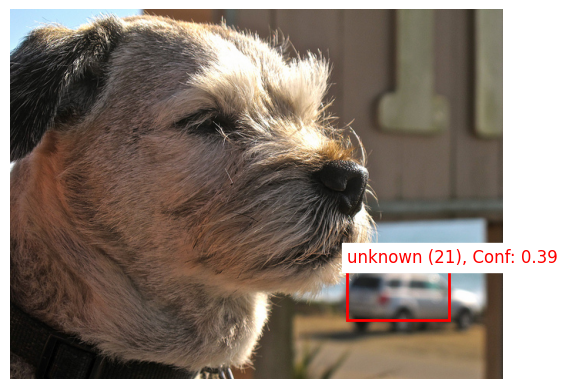

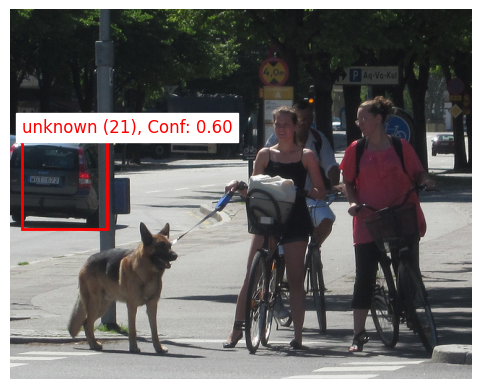

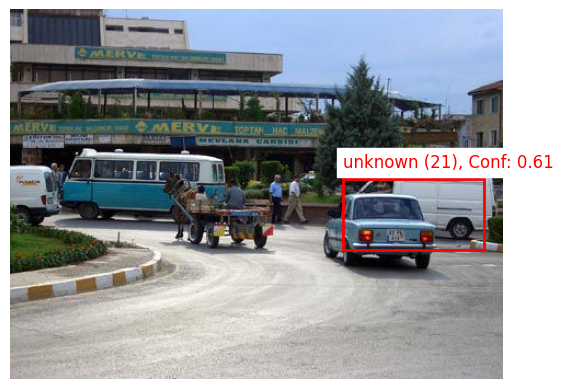

In [60]:

import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. 데이터 로드
data_path = '/workspace/PROB/exps/tag1_results.npy'
data_dict = np.load(data_path, allow_pickle=True).item()

# 데이터 추출
img_ids = data_dict['img_ids']
predictions = data_dict['predictions']
cls_list = data_dict['cls']
cls_name = data_dict['cls_name']

# 이미지 디렉토리 설정
img_dir = '/workspace/PROB/data/OWOD/JPEGImages'

# 이미지 ID별로 데이터 그룹화
from collections import defaultdict

image_data = defaultdict(list)
for img_id, pred_str, cls_id in zip(img_ids, predictions, cls_list):
    image_data[img_id].append((pred_str, cls_id))

# 각 이미지에 대해 시각화
for img_id in image_data.keys():
    # 이미지 경로 생성
    img_path = os.path.join(img_dir, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        # 이미지 ID가 숫자인 경우 6자리로 패딩
        img_path = os.path.join(img_dir, f"{int(img_id):012d}.jpg")
        if not os.path.exists(img_path):
            print(f"이미지 파일을 찾을 수 없습니다: {img_path}")
            continue

    # 이미지 로드
    image = Image.open(img_path)
    width, height = image.size

    # 플롯 생성
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    # 해당 이미지의 각 예측에 대해 바운딩 박스 그리기
    for pred_str, cls_id in image_data[img_id]:
        # 예측 문자열 파싱
        items = pred_str.split()
        img_id_p = items[0]
        conf = float(items[1])
        x1, y1, x2, y2 = map(float, items[2:6])

        # 바운딩 박스 그리기
        bbox_width = x2 - x1
        bbox_height = y2 - y1
        rect = patches.Rectangle((x1, y1), bbox_width, bbox_height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        # 클래스 이름 가져오기
        if cls_id < len(cls_name):
            class_name = cls_name[cls_id]
        else:
            class_name = 'unknown'

        # 클래스 및 신뢰도 표시
        ax.text(x1, y1 - 10, f'{class_name} ({cls_id}), Conf: {conf:.2f}', color='red', fontsize=12, backgroundcolor='white')

    plt.axis('off')
    plt.show()


##### Prompt 저장 (json file)

In [29]:
import json

prompts = []

# 각 이미지에 대해 프롬프트 생성
for img_id in image_data.keys():
    img_path = os.path.join(img_dir, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(img_dir, f"{int(img_id):012d}.jpg")
        if not os.path.exists(img_path):
            print(f"이미지 파일을 찾을 수 없습니다: {img_path}")
            continue

    prompt_rects = []
    for pred_str, cls_id in image_data[img_id]:
        category_id = int(cls_id)  # 이 부분이 중요

        items = pred_str.split()
        img_id_p = items[0]
        conf = float(items[1])
        x1, y1, x2, y2 = map(float, items[2:6])

        rect = [float(coord) for coord in [x1, y1, x2, y2]]
        
        prompt_rects.append({
            "category_id": category_id,
            "rects": [rect],
        })

    # 프롬프트 생성
    prompt = {
        "prompt_image": img_path,
        "type": "rect",
        "prompts": prompt_rects,
    }

    prompts.append(prompt)

# 프롬프트를 JSON 파일로 저장
output_file_path = '/workspace/T-Rex/tag21_output_prompts.json'
with open(output_file_path, 'w') as json_file:
    json.dump(prompts, json_file)


##### T-Rex 실행

In [30]:
# 실제 토큰으로 대체 (공개적으로 공유하지 않도록 주의)
token = ''  

!python /workspace/T-Rex/demo_examples/interactive_inference.py --token {token} --prompts_path {output_file_path}


Visualized image saved to demo_vis//interactive_0.jpg
Visualized image saved to demo_vis//interactive_1.jpg
Visualized image saved to demo_vis//interactive_2.jpg


#### 2-2 T-Rex API 사용한 annotation (Tag Multi)
- class 21: truck
- class 22: display 

In [31]:
import os
import numpy as np
from fiftyone import ViewField as F

filtered_view = (
    dataset.filter_labels("preds_overlapping_unknown_gt", F("confidence") >= 0.1)
)

session.view = filtered_view

In [38]:
# 관심있는 태그 목록 정의
tags_of_interest = ["21", "22"]

# 관심 태그 중 하나라도 포함하는 필터링 조건 생성
filter_condition = None
for tag in tags_of_interest:
    cond = F("tags").contains(tag)
    if filter_condition is None:
        filter_condition = cond
    else:
        filter_condition |= cond

# 필터링된 annotation_view 생성
annotation_view = dataset.filter_labels("preds_overlapping_unknown_gt", filter_condition)
session.view = annotation_view
annotation_view

Dataset:     t1_c20_test
Media type:  image
Num samples: 7
Sample fields:
    id:                             fiftyone.core.fields.ObjectIdField
    filepath:                       fiftyone.core.fields.StringField
    tags:                           fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                     fiftyone.core.fields.DateTimeField
    last_modified_at:               fiftyone.core.fields.DateTimeField
    predictions:                    fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    known_ground_truth:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    unknown_ground_truth:           fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    preds_without_overlap_known_gt: fiftyone.core.fields.EmbeddedDocumentField(fiftyone.co

In [42]:
img_ids = []
predictions = []
cls_list = []

for sample in annotation_view:
    image_path = sample.filepath
    img_id = os.path.splitext(os.path.basename(image_path))[0]
    
    metadata = sample.metadata
    if metadata is None:
        sample.compute_metadata()
        metadata = sample.metadata
    
    image_width = metadata.width
    image_height = metadata.height
    
    detections = sample.preds_overlapping_unknown_gt.detections
    
    for detection in detections:
        matched_tags = [t for t in detection.tags if t in tags_of_interest]
        if not matched_tags:
            continue  
        
        det_tag = matched_tags[0]
        class_id = int(det_tag)  
        
        conf = detection.confidence
        if conf is None:
            conf = 1.0
        
        bbox = detection.bounding_box  # [x, y, w, h]
        x1 = bbox[0] * image_width
        y1 = bbox[1] * image_height
        x2 = x1 + bbox[2] * image_width
        y2 = y1 + bbox[3] * image_height
        
        pred_str = f"{img_id} {conf} {x1} {y1} {x2} {y2}"
        
        img_ids.append(img_id)
        predictions.append(pred_str)
        cls_list.append(class_id)
print(cls_list)

[21, 21, 22, 22, 22, 22, 21]


In [54]:
cls_array = np.array(cls_list)

data_dict = {
    'img_ids': img_ids,
    'predictions': predictions,
    'cls': cls_array,
    'cls_name': cls_name,
}

output_file_path = '/workspace/PROB/exps/tag_multi_results.npy'
np.save(output_file_path, data_dict)

##### 내가 필터링한 데이터 확인

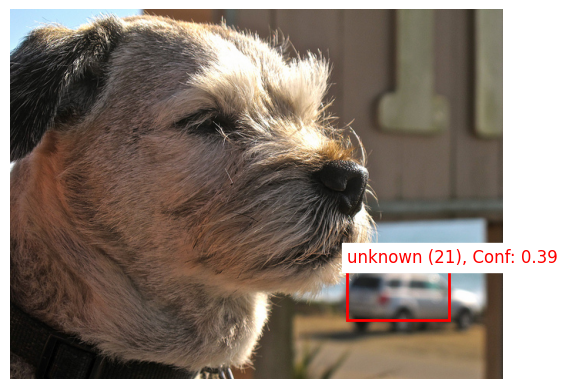

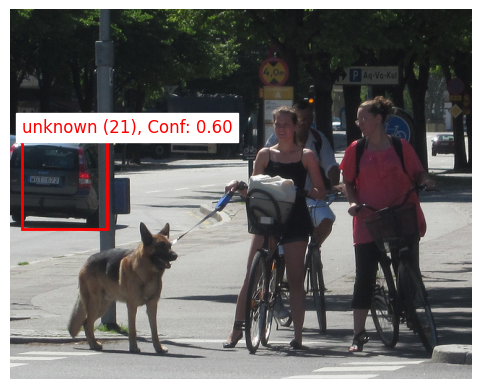

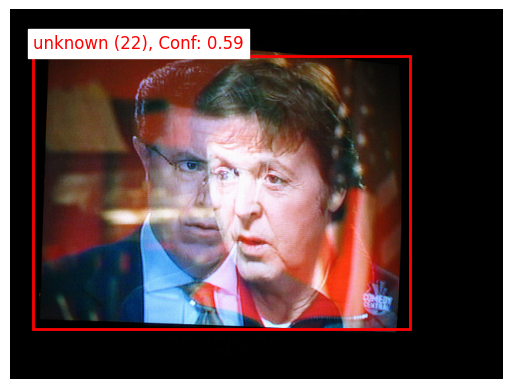

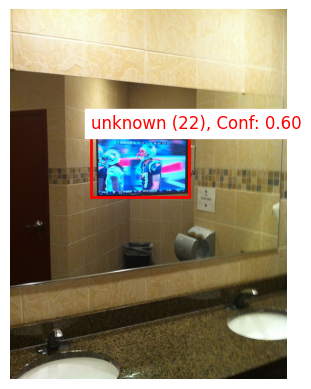

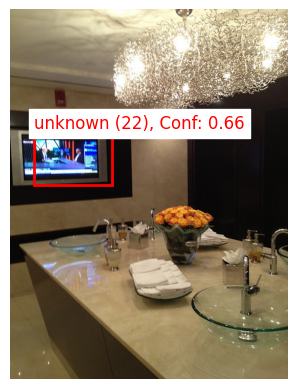

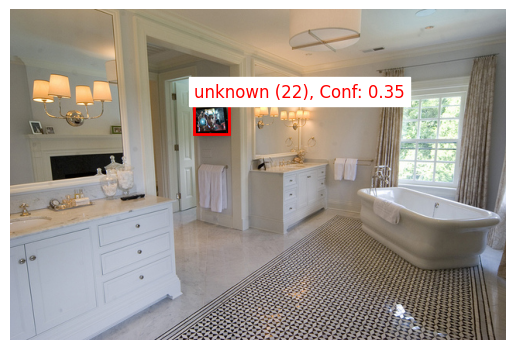

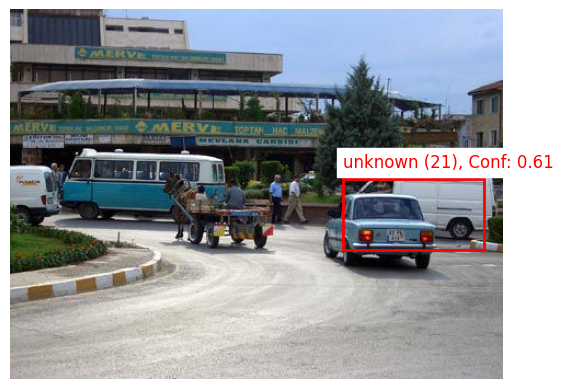

In [55]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

data_path = '/workspace/PROB/exps/tag_multi_results.npy'
data_dict = np.load(data_path, allow_pickle=True).item()

img_ids = data_dict['img_ids']
predictions = data_dict['predictions']
cls_list = data_dict['cls']
cls_name = data_dict['cls_name']

img_dir = '/workspace/PROB/data/OWOD/JPEGImages'

# 이미지 ID별로 데이터 그룹화
from collections import defaultdict

image_data = defaultdict(list)
for img_id, pred_str, cls_id in zip(img_ids, predictions, cls_list):
    image_data[img_id].append((pred_str, cls_id))

# 각 이미지에 대해 시각화
for img_id in image_data.keys():
    img_path = os.path.join(img_dir, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(img_dir, f"{int(img_id):012d}.jpg")
        if not os.path.exists(img_path):
            print(f"이미지 파일을 찾을 수 없습니다: {img_path}")
            continue

    image = Image.open(img_path)
    width, height = image.size

    fig, ax = plt.subplots(1)
    ax.imshow(image)

    # 해당 이미지의 각 예측에 대해 바운딩 박스 그리기
    for pred_str, cls_id in image_data[img_id]:
        items = pred_str.split()
        img_id_p = items[0]
        conf = float(items[1])
        x1, y1, x2, y2 = map(float, items[2:6])

        bbox_width = x2 - x1
        bbox_height = y2 - y1
        rect = patches.Rectangle((x1, y1), bbox_width, bbox_height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        # 클래스 이름 가져오기
        if cls_id < len(cls_name):
            class_name = cls_name[cls_id]
        else:
            class_name = 'unknown'

        ax.text(x1, y1 - 10, f'{class_name} ({cls_id}), Conf: {conf:.2f}', color='red', fontsize=12, backgroundcolor='white')

    plt.axis('off')
    plt.show()


##### Prompt 생성

In [48]:
import json

prompts = []

for img_id in image_data.keys():
    img_path = os.path.join(img_dir, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(img_dir, f"{int(img_id):012d}.jpg")
        if not os.path.exists(img_path):
            print(f"이미지 파일을 찾을 수 없습니다: {img_path}")
            continue

    prompt_rects = []
    for pred_str, cls_id in image_data[img_id]:
        category_id = int(cls_id)  # 이 부분이 중요

        items = pred_str.split()
        img_id_p = items[0]
        conf = float(items[1])
        x1, y1, x2, y2 = map(float, items[2:6])

        rect = [float(coord) for coord in [x1, y1, x2, y2]]
        
        prompt_rects.append({
            "category_id": category_id,
            "rects": [rect],
        })

    # 프롬프트 생성
    prompt = {
        "prompt_image": img_path,
        "type": "rect",
        "prompts": prompt_rects,
    }

    prompts.append(prompt)

# 프롬프트를 JSON 파일로 저장
output_file_path = '/workspace/T-Rex/tag_multi_output_prompts.json'
with open(output_file_path, 'w') as json_file:
    json.dump(prompts, json_file)

##### T-Rex 실행

In [47]:
import os
import json
import math

prompts_file_path = '/workspace/T-Rex/tag_multi_output_prompts.json'

t_rex_command = (
    "python /workspace/T-Rex/demo_examples/interactive_inference.py "
    "--token {token} --prompts_path {output_file_path} --vis_dir {vis_dir}"
)

# 실제 토큰으로 대체 (공개적으로 공유하지 않도록 주의)
token = ''

# 최대 batch size
batch_size = 4

with open(prompts_file_path, 'r') as file:
    all_prompts = json.load(file)

num_prompts = len(all_prompts)
num_batches = math.ceil(num_prompts / batch_size)

print(f"전체 prompt 개수: {num_prompts}")
print(f"Batch 수: {num_batches}")

result_base_dir = "/workspace/T-Rex/batch_results"
os.makedirs(result_base_dir, exist_ok=True)

for batch_idx in range(num_batches):
    start_idx = batch_idx * batch_size
    end_idx = min(start_idx + batch_size, num_prompts)
    batch_prompts = all_prompts[start_idx:end_idx]
    
    temp_prompts_path = f"/workspace/T-Rex/temp_prompts_batch_{batch_idx + 1}.json"
    with open(temp_prompts_path, 'w') as temp_file:
        json.dump(batch_prompts, temp_file)
    
    print(f"Batch {batch_idx + 1}/{num_batches}: {temp_prompts_path} 생성 완료")
    
    batch_result_dir = os.path.join(result_base_dir, f"batch_{batch_idx + 1}")
    os.makedirs(batch_result_dir, exist_ok=True)
    
    command = t_rex_command.format(token=token, output_file_path=temp_prompts_path, vis_dir=batch_result_dir)
    print(f"Executing: {command}")
    os.system(command)

print("모든 Batch 처리가 완료되었습니다.")


전체 prompt 개수: 7
Batch 수: 2
Batch 1/2: /workspace/T-Rex/temp_prompts_batch_1.json 생성 완료
Executing: python /workspace/T-Rex/demo_examples/interactive_inference.py --token d356cc9538d41eb1874d708ea373d760 --prompts_path /workspace/T-Rex/temp_prompts_batch_1.json --vis_dir /workspace/T-Rex/batch_results/batch_1
Visualized image saved to /workspace/T-Rex/batch_results/batch_1/interactive_0.jpg
Visualized image saved to /workspace/T-Rex/batch_results/batch_1/interactive_1.jpg
Visualized image saved to /workspace/T-Rex/batch_results/batch_1/interactive_2.jpg
Visualized image saved to /workspace/T-Rex/batch_results/batch_1/interactive_3.jpg
Batch 2/2: /workspace/T-Rex/temp_prompts_batch_2.json 생성 완료
Executing: python /workspace/T-Rex/demo_examples/interactive_inference.py --token d356cc9538d41eb1874d708ea373d760 --prompts_path /workspace/T-Rex/temp_prompts_batch_2.json --vis_dir /workspace/T-Rex/batch_results/batch_2
Visualized image saved to /workspace/T-Rex/batch_results/batch_2/interactive_

In [49]:
print("??")